In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

# Regression - The Ames Housing Dataset

Let's apply linear regression to the Ames Housing Dataset!

## Load and explore the data

The data set contains information from the Ames Assessor’s Office used in computing assessed values for individual residential properties sold in Ames, IA from 2006 to 2010. 
The data aren't cleaned so there are some preprocessing steps required.

In [3]:
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')

In [4]:
housing.frame

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
housing.frame.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [6]:
# check, if the data contains missing values
housing.frame.isna().sum().sum()

np.int64(6965)

In [7]:
# here is the full list of features
# features = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 
#             'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

# for this exercise, we will only use a subset of the features
#
# LotArea (Continuous): Lot size in square feet
# YearBuilt (Discrete): Original construction date
# 1stFlrSF (Continuous): First Floor square feet
# GrLivArea (Continuous): Above grade (ground) living area square feet
# GarageArea (Continuous): Size of garage in square feet
# SalePrice (Continuous): Sale price $$
#
features = ['LotArea', 'YearBuilt', '1stFlrSF', 'GrLivArea', 'GarageArea', 'SalePrice']

In [11]:
df = housing.frame[features]

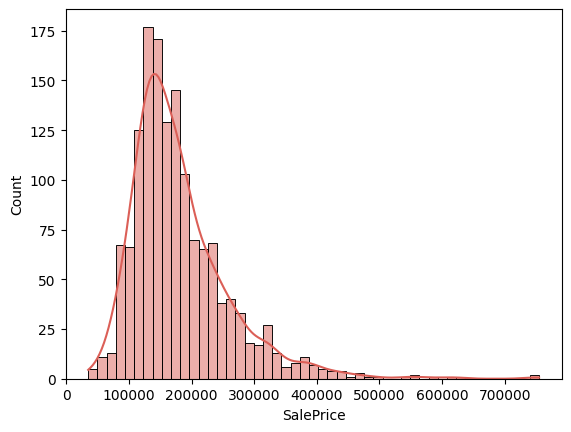

In [12]:
# let's look at the target 
sns.histplot(data=df, x="SalePrice", kde=True, color=sns.color_palette("hls", 9)[0]);

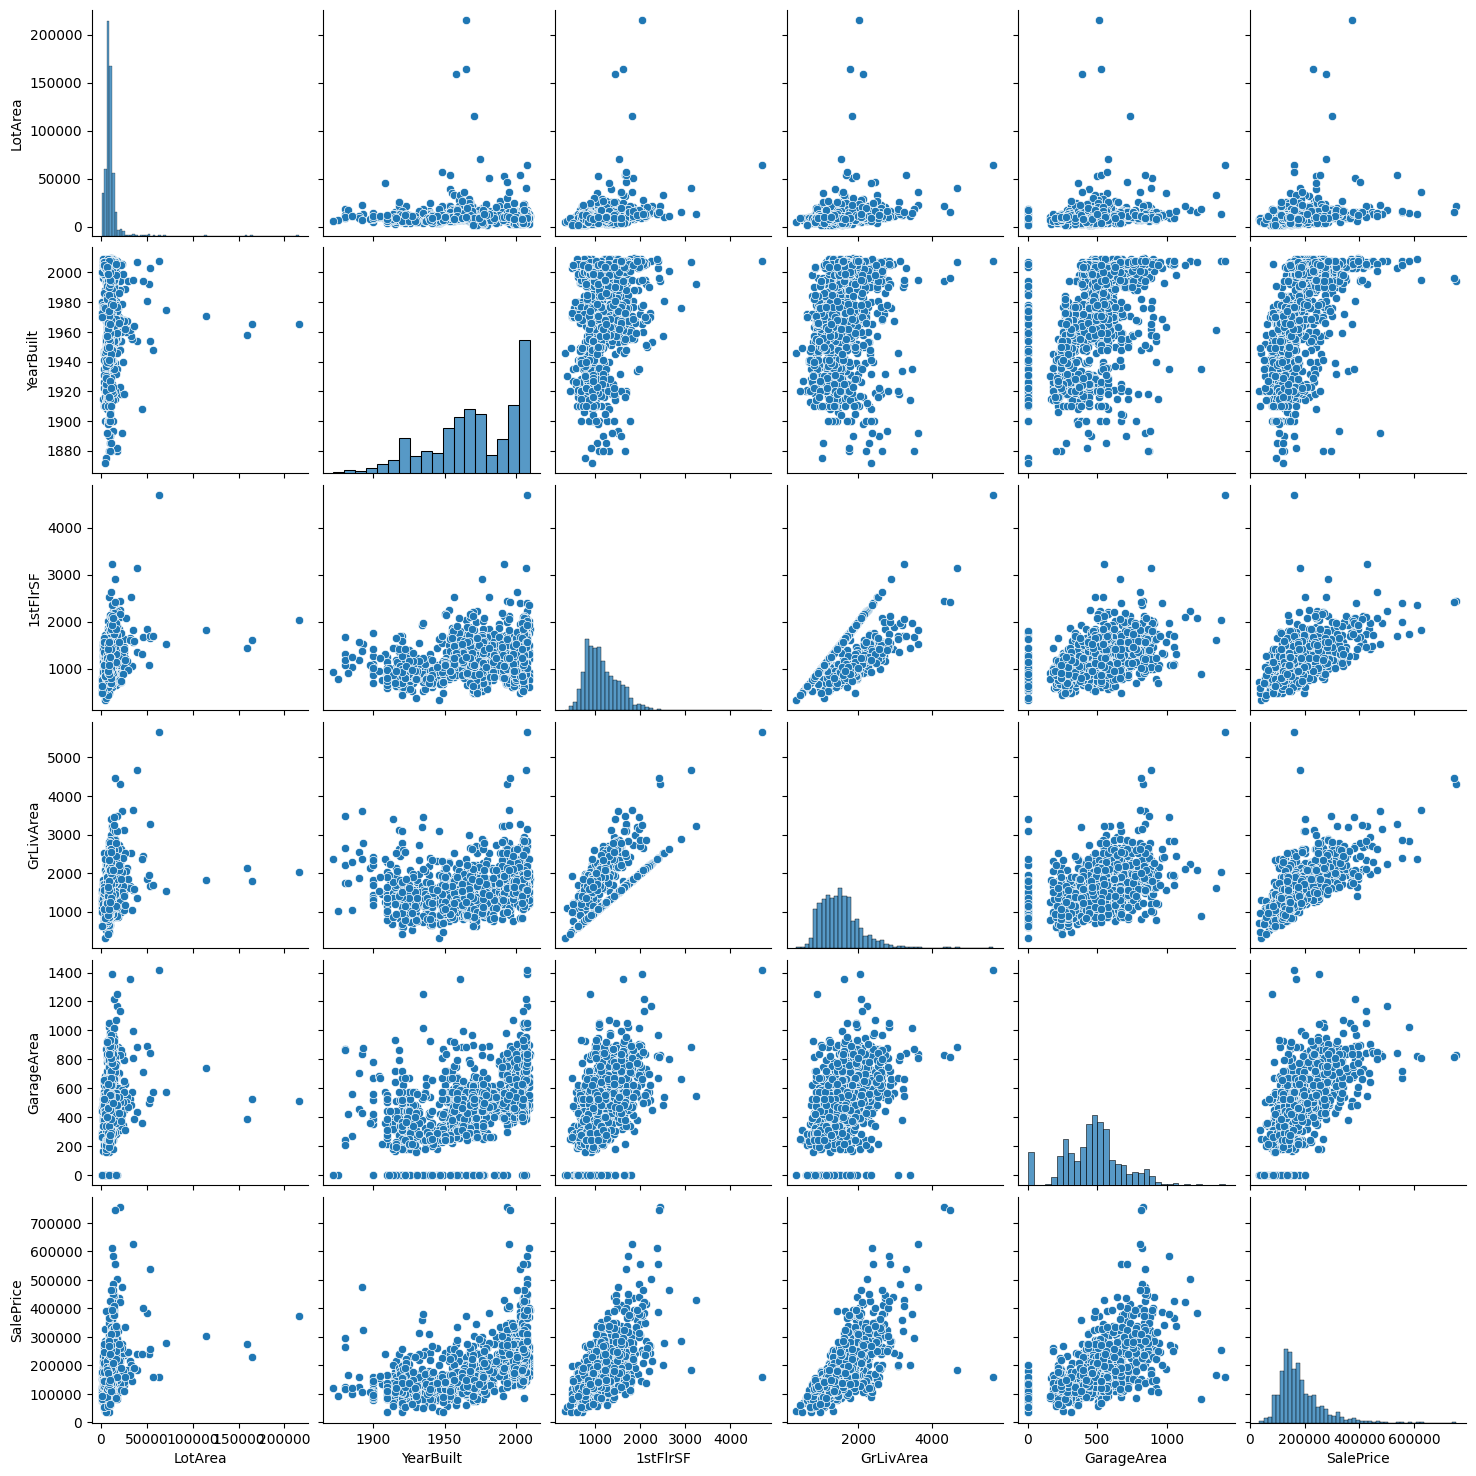

In [13]:
# a pairplot might be valuable
sns.pairplot(df);

In [14]:
df2 = df.dropna()
print(f'Before {df.shape[0]} After {df2.shape[0]} -> removed {df.shape[0]-df2.shape[0]} NaNs')

Before 1460 After 1460 -> removed 0 NaNs


In [15]:
df_clean = df2[(df2-df2.mean()).abs() <= df2.std()*3].dropna()
print(f'Before {df2.shape[0]} After {df_clean.shape[0]} -> removed {df2.shape[0]-df_clean.shape[0]} Outliers')

Before 1460 After 1405 -> removed 55 Outliers


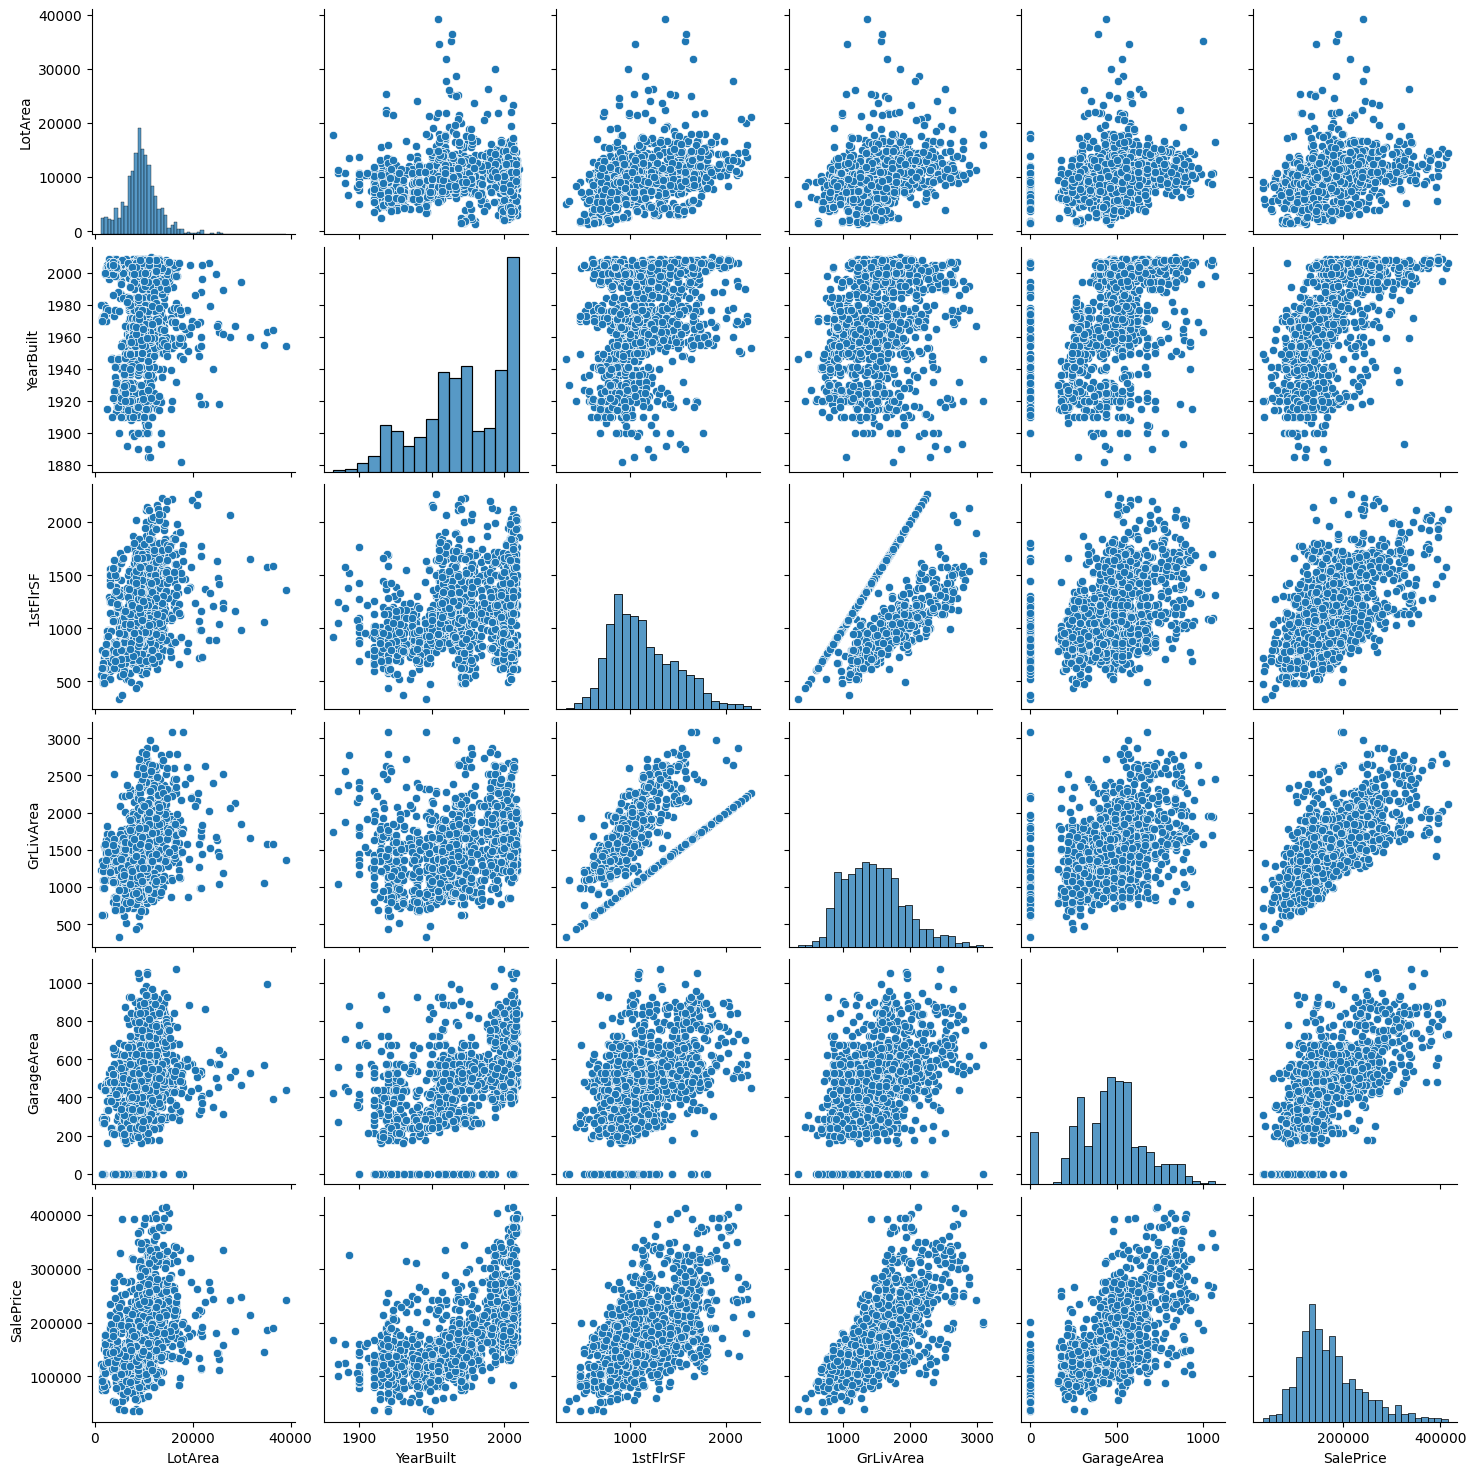

In [16]:
sns.pairplot(df_clean);

## Preparation

In [17]:
# Let's define a function to evalute a model

def eval_lm(name, lm, X_train, y_train, X_test, y_test):
    y_pred_lm_train = lm.predict(X_train)
    y_pred_lm_test = lm.predict(X_test)

    RMSE_lm_train = metrics.root_mean_squared_error(y_train, y_pred_lm_train)
    RMSE_lm_test = metrics.root_mean_squared_error(y_test, y_pred_lm_test)

    r2_lm_train = lm.score(X_train, y_train)
    r2_lm_test = lm.score(X_test, y_test)

    print(f"{name}: RMSE(train) = {RMSE_lm_train:.4f}  RMSE(test) = {RMSE_lm_test:.4f}  r2(train)  = {r2_lm_train:.4f}  r2(test)  = {r2_lm_test:.4f}")

# Multiple Regression

Let's do very basic multiple regression first - no preprocessing of the data, no regularization. 

In [18]:
# Let's split the data into train and test dataset
target_name = "SalePrice"
test_size = 0.2
X, y = df_clean.drop(columns=target_name), df_clean[target_name]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
print(f"# train = {len(X_train)}, # test = {len(X_test)}, # total = {len(df_clean)}")

# train = 1124, # test = 281, # total = 1405


In [19]:
blm = LinearRegression()
blm.fit(X_train, y_train)
eval_lm('blm', blm, X_train, y_train, X_test, y_test)

blm: RMSE(train) = 33462.9322  RMSE(test) = 30375.1120  r2(train)  = 0.7390  r2(test)  = 0.7849


Discussion: train and test scores are roughly similar, test is larger than train, this looks like underfitting.

# Polynomial Regression

**Exercise 1**: The given code trains polynomial models for degress 2, 3, 4, 5, 6, 7. Execute it and compare the results to the linear model and discuss. You will be getting very strange r2 values - what do you think is the reason for these values (think about it - if you understand r2, than you should be able to solve this without google!)?

In [20]:
for i in range(2,8):
    poly = PolynomialFeatures(i)
    Xp = pd.DataFrame(poly.fit_transform(X))
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, test_size=test_size, random_state=42)
    plm = LinearRegression()
    plm.fit(X_train, y_train)
    eval_lm(f'plm_{str(i)}', plm, X_train, y_train, X_test, y_test)

plm_2: RMSE(train) = 29778.3446  RMSE(test) = 25355.5765  r2(train)  = 0.7933  r2(test)  = 0.8501
plm_3: RMSE(train) = 28641.9993  RMSE(test) = 23997.3974  r2(train)  = 0.8088  r2(test)  = 0.8657
plm_4: RMSE(train) = 27116.6718  RMSE(test) = 25655.4468  r2(train)  = 0.8286  r2(test)  = 0.8465
plm_5: RMSE(train) = 24987.1335  RMSE(test) = 45444.9649  r2(train)  = 0.8545  r2(test)  = 0.5185
plm_6: RMSE(train) = 23708.2089  RMSE(test) = 98862.4765  r2(train)  = 0.8690  r2(test)  = -1.2789
plm_7: RMSE(train) = 23164.1581  RMSE(test) = 241747.6339  r2(train)  = 0.8749  r2(test)  = -12.6265


In [17]:
# plm_5 and onward have such strange r2 values due to overfitting

# Regularization

For all of the following exercises, try different lambda/alpha values of 0.1, 0.5, 1, 10, 100 and increase the maximum number of iterations **max_iter** to 20000 and the tolerance **tol** to 0.1 for all the following regularization trials.

In [27]:
alphas = [0.1, 0.5, 1, 10, 100]
max_iter=20000
tol=0.1

## Ridge Regression

**Exercise 2**: pick the most promising polynomial model (what is you decision criterion?) and try ridge regression (for the alphas given above, using the max_iter and tol from above). Interpret your result.

NOTE: You may be getting a warning (ill-conditioned matrix) - you can ignore this for now, it means that the feature values are to "broad" (high/low). This is a clear indication, that we need to normalize the features (which we will do below).

In [30]:
# polynomial model 4 was chosen due to being close in values for RMSE and r2, meaning there is only slight overfitting (?)
for i in alphas:
    poly = PolynomialFeatures(4)
    Xp = pd.DataFrame(poly.fit_transform(X))
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, test_size=test_size, random_state=42)
    plm = Ridge(alpha=i, max_iter=max_iter, tol=tol)
    plm.fit(X_train, y_train)
    eval_lm(f'alpha_{str(i)}', plm, X_train, y_train, X_test, y_test)
# linear regression: plm_4: RMSE(train) = 27116.6718  RMSE(test) = 25655.4468  r2(train)  = 0.8286  r2(test)  = 0.8465
# alpha_0.1: RMSE(train) = 25834.9834  RMSE(test) = 26425.6863  r2(train)  = 0.8444  r2(test)  = 0.8372
# alpha_0.5: RMSE(train) = 25849.6942  RMSE(test) = 26695.8657  r2(train)  = 0.8443  r2(test)  = 0.8338
# alpha_1: RMSE(train) = 25852.6494  RMSE(test) = 26749.1332  r2(train)  = 0.8442  r2(test)  = 0.8332
# alpha_10: RMSE(train) = 25855.6656  RMSE(test) = 26803.0636  r2(train)  = 0.8442  r2(test)  = 0.8325
# alpha_100: RMSE(train) = 25855.9902  RMSE(test) = 26808.9857  r2(train)  = 0.8442  r2(test)  = 0.8324
# has improved the model for the training data but significantly for the training data

# trying it with polynomial model 5
for i in alphas:
    poly = PolynomialFeatures(5)
    Xp = pd.DataFrame(poly.fit_transform(X))
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, test_size=test_size, random_state=42)
    plm = Ridge(alpha=i, max_iter=max_iter, tol=tol)
    plm.fit(X_train, y_train)
    eval_lm(f'plm5_alpha_{str(i)}', plm, X_train, y_train, X_test, y_test)
# linear regression: plm_5: RMSE(train) = 24987.1335  RMSE(test) = 45444.9649  r2(train)  = 0.8545  r2(test)  = 0.5185
# alpha_plm5_0.1: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
# alpha_plm5_0.5: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
# alpha_plm5_1: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
# alpha_plm5_10: RMSE(train) = 24919.9549  RMSE(test) = 155225.3389  r2(train)  = 0.8553  r2(test)  = -4.6181
# alpha_plm5_100: RMSE(train) = 22400.9636  RMSE(test) = 82617.0179  r2(train)  = 0.8831  r2(test)  = -0.5915
# the model did not improve

C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.36556483385476e-39.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.675954234444828e-38.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.353824089712932e-38.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.353418514195499

alpha_0.1: RMSE(train) = 25834.9834  RMSE(test) = 26425.6863  r2(train)  = 0.8444  r2(test)  = 0.8372
alpha_0.5: RMSE(train) = 25849.6942  RMSE(test) = 26695.8657  r2(train)  = 0.8443  r2(test)  = 0.8338
alpha_1: RMSE(train) = 25852.6494  RMSE(test) = 26749.1332  r2(train)  = 0.8442  r2(test)  = 0.8332
alpha_10: RMSE(train) = 25855.6656  RMSE(test) = 26803.0636  r2(train)  = 0.8442  r2(test)  = 0.8325
alpha_100: RMSE(train) = 25855.9902  RMSE(test) = 26808.9857  r2(train)  = 0.8442  r2(test)  = 0.8324
alpha_plm5_0.1: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
alpha_plm5_0.5: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
alpha_plm5_1: RMSE(train) = 32030.6473  RMSE(test) = 84768.8795  r2(train)  = 0.7609  r2(test)  = -0.6755
alpha_plm5_10: RMSE(train) = 24919.9549  RMSE(test) = 155225.3389  r2(train)  = 0.8553  r2(test)  = -4.6181
alpha_plm5_100: RMSE(train) = 22400.9636  RMSE(test) = 82617.01

C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1739706588302602e-46.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jihre\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.3267313546089264e-45.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


## Lasso Regression

**Exercise 3**: Try lasso regression and interpret your result.

In [31]:
# Solution
for i in alphas:
    poly = PolynomialFeatures(4)
    Xp = pd.DataFrame(poly.fit_transform(X))
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, test_size=test_size, random_state=42)
    plm = Lasso(alpha=i, max_iter=max_iter, tol=tol)
    plm.fit(X_train, y_train)
    eval_lm(f'plm4_alpha_{str(i)}', plm, X_train, y_train, X_test, y_test)
# linear regression: plm_4: RMSE(train) = 29938.0240  RMSE(test) = 25013.6104  r2(train)  = 0.7911  r2(test)  = 0.8541
# lasso regression has improved the model for both data sets

plm4_alpha_0.1: RMSE(train) = 29294.2130  RMSE(test) = 24474.5913  r2(train)  = 0.8000  r2(test)  = 0.8603
plm4_alpha_0.5: RMSE(train) = 29294.2231  RMSE(test) = 24474.5901  r2(train)  = 0.8000  r2(test)  = 0.8603
plm4_alpha_1: RMSE(train) = 29293.8265  RMSE(test) = 24474.2950  r2(train)  = 0.8000  r2(test)  = 0.8603
plm4_alpha_10: RMSE(train) = 29291.6072  RMSE(test) = 24472.5191  r2(train)  = 0.8000  r2(test)  = 0.8604
plm4_alpha_100: RMSE(train) = 29267.0568  RMSE(test) = 24453.5308  r2(train)  = 0.8004  r2(test)  = 0.8606


## ElasticNet Regression

**Exercise 4**: Try ElasticNet regression and interpret your result.

Note: actually, we should also vary the value for l1_ratio (what we called rho in the lecture), which controls the strength of L1 vs. L2 regularization. Fell free to use GridSearchCV to try the alphas given above in combination with l1_ratios, if you are familiar with GridSearchCV.

In [32]:
# Solution
for i in alphas:
    poly = PolynomialFeatures(4)
    Xp = pd.DataFrame(poly.fit_transform(X))
    X_train, X_test, y_train, y_test = train_test_split(Xp, y, test_size=test_size, random_state=42)
    plm = ElasticNet(alpha=i, max_iter=max_iter, tol=tol)
    plm.fit(X_train, y_train)
    eval_lm(f'plm4_alpha_{str(i)}', plm, X_train, y_train, X_test, y_test)

# elastic net has also improved for both data sets

plm4_alpha_0.1: RMSE(train) = 29252.8451  RMSE(test) = 24439.5906  r2(train)  = 0.8006  r2(test)  = 0.8607
plm4_alpha_0.5: RMSE(train) = 29129.8764  RMSE(test) = 24346.1979  r2(train)  = 0.8022  r2(test)  = 0.8618
plm4_alpha_1: RMSE(train) = 29104.0367  RMSE(test) = 24326.8840  r2(train)  = 0.8026  r2(test)  = 0.8620
plm4_alpha_10: RMSE(train) = 29166.2852  RMSE(test) = 24384.3198  r2(train)  = 0.8017  r2(test)  = 0.8614
plm4_alpha_100: RMSE(train) = 28975.1863  RMSE(test) = 24426.4725  r2(train)  = 0.8043  r2(test)  = 0.8609


# Feature Normalization

In the lecture, we discussed that ridge and lasso regression are not scale invariant, so it makes sense to normalize the features to the same range. For this, we will use the StandardScaler, which normalizes each feature to mean=0 and standard deviation=1 (thus, variance=1 as well).

The best approach to do so is to use a pipeline, which first Normalizes the features and than pipes these into the model. This way, both the training data and the test/production data will be normalized. Here is a code example for create a basic linear model with feature normalization:

  **model = make_pipeline(StandardScaler(), LinearRegression())**
  
**Exercise 5**: Try Ridge, Lasso and ElasticNet regression with normalization and interpret your results.

In [27]:
# Solution

------